# Crack Detection — DenseNet121 (PyTorch)
Transfer Learning + Fine-Tuning untuk klasifikasi retakan: Diagonal, Horizontal, Vertikal.

**Versi PyTorch — GPU-ready:**
- ✅ Framework: PyTorch + torchvision (bukan TensorFlow)
- ✅ Otomatis pakai GPU jika tersedia (`cuda`), fallback ke CPU
- ✅ Preprocessing ImageNet-standard via `torchvision.transforms`
- ✅ Unfreeze 40% parameter terakhir (proporsional, bukan angka absolut)
- ✅ Learning rate `1e-4` (DenseNet cukup toleran)

In [1]:
%pip install torch torchvision scikit-learn matplotlib seaborn numpy pillow tqdm -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.models import densenet121, DenseNet121_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, \
    f1_score, precision_score, recall_score
import pandas as pd

# ── Device ─────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch version : {torch.__version__}')
print(f'Device          : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU Name        : {torch.cuda.get_device_name(0)}')
    print(f'VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

PyTorch version : 2.5.1+cu121
Device          : cuda
GPU Name        : NVIDIA GeForce RTX 3050 Laptop GPU
VRAM            : 4.3 GB


## Konfigurasi

In [3]:
DATASET_DIR = './dataset'
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 16
EPOCHS      = 50
NUM_CLASSES = 3
CLASS_NAMES = ['Diagonal', 'Horizontal', 'Vertikal']
TRAIN_SPLIT = 0.70
VAL_SPLIT   = 0.15
TEST_SPLIT  = 0.15
SEED        = 42
MODEL_NAME  = 'DenseNet121'

# Reproducibility
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True

print(f'Dataset  : {DATASET_DIR}')
print(f'Img Size : {IMG_SIZE}')
print(f'Model    : {MODEL_NAME}')
print(f'Device   : {DEVICE}')

Dataset  : ./dataset
Img Size : (224, 224)
Model    : DenseNet121
Device   : cuda


## Cek Dataset

  Diagonal    :  540 gambar
  Horizontal  :  501 gambar
  Vertikal    :  500 gambar

  Train      : ~1078 gambar
  Validation : ~231 gambar
  Test       : ~231 gambar


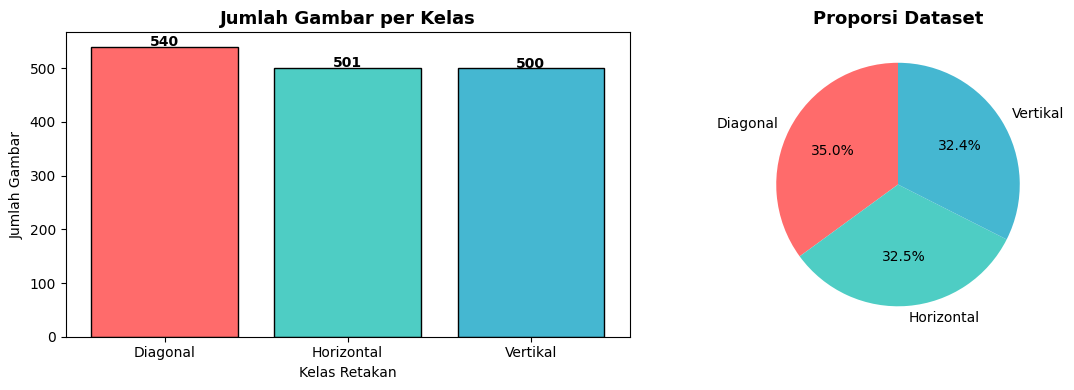

In [4]:
assert os.path.exists(DATASET_DIR), f'Dataset tidak ditemukan: {DATASET_DIR}'

total  = 0
counts = {}
for cls in CLASS_NAMES:
    cls_path = os.path.join(DATASET_DIR, cls)
    if os.path.exists(cls_path):
        n = len([f for f in os.listdir(cls_path)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))])
        counts[cls] = n
        total += n
        print(f'  {cls:12s}: {n:4d} gambar')
    else:
        print(f'  {cls} — folder tidak ditemukan!')

print(f'\n  Train      : ~{int(total*TRAIN_SPLIT)} gambar')
print(f'  Validation : ~{int(total*VAL_SPLIT)} gambar')
print(f'  Test       : ~{int(total*TEST_SPLIT)} gambar')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(counts.keys(), counts.values(), color=['#FF6B6B','#4ECDC4','#45B7D1'], edgecolor='black')
axes[0].set_title('Jumlah Gambar per Kelas', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Kelas Retakan')
axes[0].set_ylabel('Jumlah Gambar')
for i,(k,v) in enumerate(counts.items()):
    axes[0].text(i, v+1, str(v), ha='center', fontweight='bold')
axes[1].pie(counts.values(), labels=counts.keys(), autopct='%1.1f%%',
            colors=['#FF6B6B','#4ECDC4','#45B7D1'], startangle=90)
axes[1].set_title('Proporsi Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'distribusi_dataset_{MODEL_NAME.lower()}.png', dpi=150, bbox_inches='tight')
plt.show()

## Load & Split Dataset (70/15/15)

In [5]:
all_images, all_labels = [], []
for label_idx, cls in enumerate(CLASS_NAMES):
    cls_path = os.path.join(DATASET_DIR, cls)
    for fname in os.listdir(cls_path):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
            all_images.append(os.path.join(cls_path, fname))
            all_labels.append(label_idx)

combined = list(zip(all_images, all_labels))
random.seed(SEED)
random.shuffle(combined)
all_images, all_labels = zip(*combined)
all_images = list(all_images)
all_labels = list(all_labels)

X_train, X_temp, y_train, y_temp = train_test_split(
    all_images, all_labels,
    test_size=(VAL_SPLIT + TEST_SPLIT),
    random_state=SEED, stratify=all_labels
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5,
    random_state=SEED, stratify=y_temp
)

print(f'  Train      : {len(X_train):4d} gambar ({len(X_train)/len(all_images)*100:.1f}%)')
print(f'  Validation : {len(X_val):4d} gambar ({len(X_val)/len(all_images)*100:.1f}%)')
print(f'  Test       : {len(X_test):4d} gambar ({len(X_test)/len(all_images)*100:.1f}%)')

  Train      : 1078 gambar (70.0%)
  Validation :  231 gambar (15.0%)
  Test       :  232 gambar (15.1%)


## Dataset PyTorch & Augmentasi

> **PyTorch:** Preprocessing via `torchvision.transforms`.  
> ImageNet mean/std: `[0.485, 0.456, 0.406]` / `[0.229, 0.224, 0.225]`.  
> Augmentasi hanya training set. Flip **tidak digunakan** karena mengubah orientasi retakan.

In [6]:
# ── Transforms ────────────────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((IMG_SIZE[0] + 20, IMG_SIZE[1] + 20)),
    T.RandomCrop(IMG_SIZE),           # ≈ random zoom crop
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),                     # [0,255]→[0,1], HWC→CHW
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_test_transform = T.Compose([
    T.Resize(IMG_SIZE),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])


# ── Custom Dataset ─────────────────────────────────────────────
class CrackDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels      = labels
        self.transform   = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img   = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label


# ── DataLoaders ────────────────────────────────────────────────
train_dataset = CrackDataset(X_train, y_train, transform=train_transform)
val_dataset   = CrackDataset(X_val,   y_val,   transform=val_test_transform)
test_dataset  = CrackDataset(X_test,  y_test,  transform=val_test_transform)

# num_workers=0 agar kompatibel di Windows (multiprocessing limitation)
# pin_memory hanya aktif saat pakai GPU
NUM_WORKERS = 0  # ganti ke 2-4 jika pakai Linux/Mac untuk speed

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == 'cuda'),
                          persistent_workers=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == 'cuda'),
                          persistent_workers=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == 'cuda'),
                          persistent_workers=False)

print(f'  Train batches      : {len(train_loader)}')
print(f'  Validation batches : {len(val_loader)}')
print(f'  Test batches       : {len(test_loader)}')

  Train batches      : 68
  Validation batches : 15
  Test batches       : 15


## Build Model DenseNet121

> Backbone dari torchvision dengan pretrained ImageNet weights.  
> Unfreeze 40% parameter terakhir secara proporsional.  
> Custom head: `BatchNorm → Dense(256, GELU) → Dropout(0.4) → Dense(128, GELU) → Dropout(0.3) → Dense(3)`.

In [7]:
def build_densenet121(num_classes=NUM_CLASSES):
    weights  = DenseNet121_Weights.IMAGENET1K_V1
    backbone = densenet121(weights=weights)

    # Freeze semua parameter dulu
    for param in backbone.parameters():
        param.requires_grad = False

    # Unfreeze 40% parameter terakhir (proporsional)
    all_params   = list(backbone.parameters())
    freeze_until = int(len(all_params) * 0.6)
    for i, param in enumerate(all_params):
        param.requires_grad = (i >= freeze_until)

    in_features = backbone.classifier.in_features
    backbone.classifier = nn.Sequential(
        nn.BatchNorm1d(in_features),
        nn.Linear(in_features, 256),
        nn.GELU(),
        nn.Dropout(0.4),
        nn.Linear(256, 128),
        nn.GELU(),
        nn.Dropout(0.3),
        nn.Linear(128, num_classes)
    )

    return backbone


model = build_densenet121()
model = model.to(DEVICE)

total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'  Total params     : {total_p:,}')
print(f'  Trainable params : {trainable_p:,}')
print(f'  Frozen params    : {total_p - trainable_p:,}')

  Total params     : 7,251,587
  Trainable params : 4,096,259
  Frozen params    : 3,155,328


## Training

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-8, verbose=True
)

# ── Training loop ───────────────────────────────────────────────
history      = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
patience_cnt = 0
PATIENCE     = 7
best_weights = None

for epoch in range(1, EPOCHS + 1):
    # ── TRAIN ──
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in tqdm(train_loader, desc=f'Epoch {epoch:02d}/{EPOCHS} [Train]', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        _, predicted  = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += imgs.size(0)
    train_loss = running_loss / total
    train_acc  = correct / total

    # ── VALIDATION ──
    model.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs  = model(imgs)
            loss     = criterion(outputs, labels)
            val_loss_sum += loss.item() * imgs.size(0)
            _, predicted  = outputs.max(1)
            val_correct  += predicted.eq(labels).sum().item()
            val_total    += imgs.size(0)
    val_loss = val_loss_sum / val_total
    val_acc  = val_correct  / val_total

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    scheduler.step(val_loss)

    print(f'Epoch {epoch:02d}/{EPOCHS}  '
          f'train_loss={train_loss:.4f}  train_acc={train_acc:.4f}  '
          f'val_loss={val_loss:.4f}  val_acc={val_acc:.4f}')

    # ── EarlyStopping ──
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_cnt = 0
        best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        torch.save(best_weights, f'best_{MODEL_NAME}.pth')
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f'\nEarlyStopping triggered setelah epoch {epoch}')
            break

# Restore best weights
model.load_state_dict({k: v.to(DEVICE) for k, v in best_weights.items()})
print(f'\nBest val_acc: {best_val_acc*100:.2f}%')

Epoch 01/50  train_loss=0.9586  train_acc=0.6150  val_loss=0.6702  val_acc=0.8571


Epoch 02/50  train_loss=0.3850  train_acc=0.8813  val_loss=0.2585  val_acc=0.9307


Epoch 03/50  train_loss=0.1910  train_acc=0.9416  val_loss=0.2191  val_acc=0.9221


Epoch 04/50  train_loss=0.1544  train_acc=0.9518  val_loss=0.2128  val_acc=0.9134


Epoch 05/50  train_loss=0.1441  train_acc=0.9536  val_loss=0.2628  val_acc=0.8961


...

Epoch 09/50  train_loss=0.0631  train_acc=0.9805  val_loss=0.2807  val_acc=0.9221


Epoch 10/50  train_loss=0.0613  train_acc=0.9833  val_loss=0.2489  val_acc=0.9134


Epoch 11/50  train_loss=0.0319  train_acc=0.9907  val_loss=0.2582  val_acc=0.9177


Epoch 12/50  train_loss=0.0393  train_acc=0.9879  val_loss=0.3012  val_acc=0.9134


Epoch 13/50  train_loss=0.0268  train_acc=0.9917  val_loss=0.2992  val_acc=0.9264

EarlyStopping triggered setelah epoch 13

Best val_acc: 93.51%


## Grafik Training History

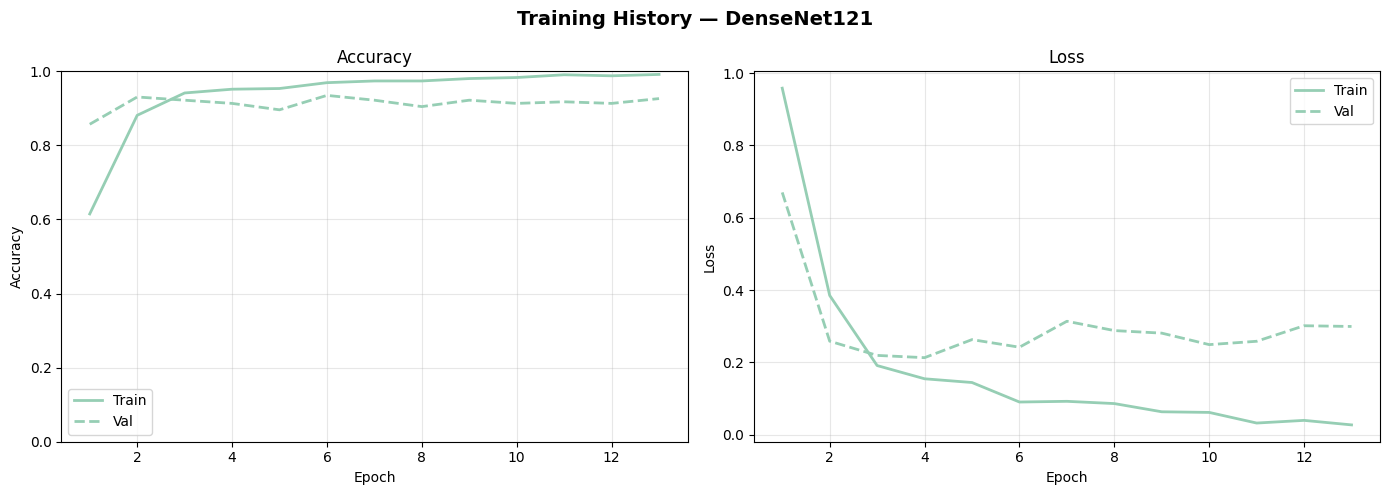

In [9]:
from matplotlib.ticker import MaxNLocator

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Training History — {MODEL_NAME}', fontsize=14, fontweight='bold')
color = '#96CEB4'

epochs_ran = range(1, len(history['train_acc']) + 1)

axes[0].plot(epochs_ran, history['train_acc'], label='Train', color=color, linewidth=2)
axes[0].plot(epochs_ran, history['val_acc'],   label='Val',   color=color, linewidth=2, linestyle='--')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1])

axes[1].plot(epochs_ran, history['train_loss'], label='Train', color=color, linewidth=2)
axes[1].plot(epochs_ran, history['val_loss'],   label='Val',   color=color, linewidth=2, linestyle='--')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'training_history_{MODEL_NAME}.png', dpi=150, bbox_inches='tight')
plt.show()

## Evaluasi pada Test Set

In [10]:
model.eval()
test_loss_sum, test_correct, test_total = 0.0, 0, 0
y_true_all, y_pred_all = [], []

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc='Evaluasi Test Set'):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs  = model(imgs)
        loss     = criterion(outputs, labels)
        test_loss_sum += loss.item() * imgs.size(0)
        _, predicted   = outputs.max(1)
        test_correct  += predicted.eq(labels).sum().item()
        test_total    += imgs.size(0)
        y_true_all.extend(labels.cpu().numpy())
        y_pred_all.extend(predicted.cpu().numpy())

test_loss  = test_loss_sum / test_total
test_acc   = test_correct  / test_total
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

print(f'\n  Test Loss     : {test_loss:.4f}')
print(f'  Test Accuracy : {test_acc*100:.2f}%')

Evaluasi Test Set: 100%|██████████| 15/15 [00:04<00:00,  3.56it/s]


  Test Loss     : 0.1968
  Test Accuracy : 93.97%


## Confusion Matrix

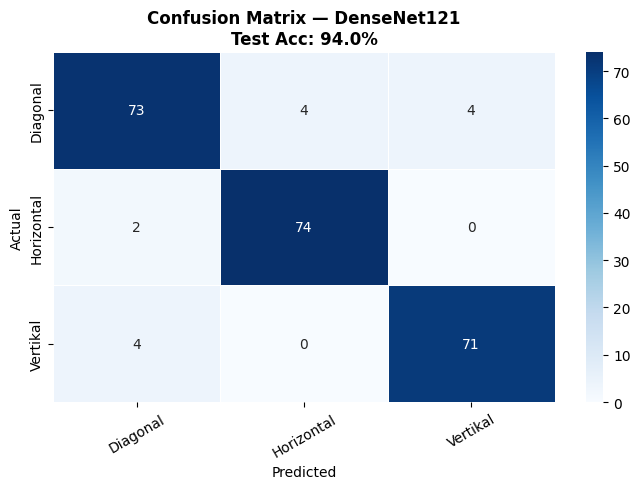

In [11]:
cm = confusion_matrix(y_true_all, y_pred_all)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cmap='Blues', linewidths=0.5)
plt.title(f'Confusion Matrix — {MODEL_NAME}\nTest Acc: {test_acc*100:.1f}%',
          fontsize=12, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f'confusion_matrix_{MODEL_NAME}.png', dpi=150, bbox_inches='tight')
plt.show()

## Classification Report

In [12]:
print(f'Classification Report — {MODEL_NAME}')
print('='*60)
print(classification_report(y_true_all, y_pred_all, target_names=CLASS_NAMES))

best_val_acc_pct = max(history['val_acc'])
df_result = pd.DataFrame([{
    'Model'       : MODEL_NAME,
    'Val Acc (%)' : f'{best_val_acc_pct*100:.2f}',
    'Test Acc (%)': f'{test_acc*100:.2f}',
    'Precision'   : f'{precision_score(y_true_all, y_pred_all, average="macro")*100:.2f}',
    'Recall'      : f'{recall_score(y_true_all, y_pred_all, average="macro")*100:.2f}',
    'F1-Score'    : f'{f1_score(y_true_all, y_pred_all, average="macro")*100:.2f}',
}])
print(df_result.to_string(index=False))
df_result.to_csv(f'hasil_{MODEL_NAME}.csv', index=False)

Classification Report — DenseNet121
              precision    recall  f1-score   support

    Diagonal       0.92      0.90      0.91        81
  Horizontal       0.95      0.97      0.96        76
    Vertikal       0.95      0.95      0.95        75

    accuracy                           0.94       232
   macro avg       0.94      0.94      0.94       232
weighted avg       0.94      0.94      0.94       232

      Model Val Acc (%) Test Acc (%) Precision Recall F1-Score
DenseNet121       93.51        93.97     93.98  94.05    94.01


## Uji Gambar Custom

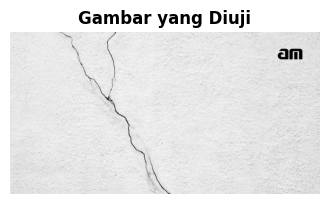

  Prediksi   : Vertikal
  Keyakinan  : 68.84%
    Diagonal    : 30.51%
    Horizontal  : 0.65%
    Vertikal    : 68.84%


In [13]:
TEST_IMAGE_PATH = './dataset/test/image2.png'

if os.path.exists(TEST_IMAGE_PATH):
    img_pil = Image.open(TEST_IMAGE_PATH).convert('RGB')

    plt.figure(figsize=(4, 4))
    plt.imshow(img_pil)
    plt.title('Gambar yang Diuji', fontweight='bold')
    plt.axis('off')
    plt.show()

    img_tensor = val_test_transform(img_pil).unsqueeze(0).to(DEVICE)

    model.eval()
    with torch.no_grad():
        outputs = model(img_tensor)
        probs   = torch.softmax(outputs, dim=1)[0]

    pred_idx   = probs.argmax().item()
    confidence = probs[pred_idx].item() * 100

    print(f'  Prediksi   : {CLASS_NAMES[pred_idx]}')
    print(f'  Keyakinan  : {confidence:.2f}%')
    for i, cls in enumerate(CLASS_NAMES):
        print(f'    {cls:12s}: {probs[i].item()*100:.2f}%')
else:
    print(f'File tidak ditemukan: {TEST_IMAGE_PATH}')

## Simpan Model

In [14]:
# Simpan state dict (untuk resume training / fine-tuning lanjutan)
torch.save(model.state_dict(), f'cracksense_{MODEL_NAME}.pth')
print(f'Model disimpan: cracksense_{MODEL_NAME}.pth')

# Ekspor sebagai TorchScript (untuk deployment/inferensi tanpa Python class)
model.eval()
example_input = torch.randn(1, 3, *IMG_SIZE).to(DEVICE)
scripted = torch.jit.trace(model, example_input)
scripted.save(f'cracksense_{MODEL_NAME}_scripted.pt')
size_mb = os.path.getsize(f'cracksense_{MODEL_NAME}_scripted.pt') / (1024*1024)
print(f'TorchScript disimpan: cracksense_{MODEL_NAME}_scripted.pt ({size_mb:.2f} MB)')

Model disimpan: cracksense_DenseNet121.pth
TorchScript disimpan: cracksense_DenseNet121_scripted.pt (29.04 MB)
